In [57]:
import os
import tabulate
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import pyarrow
import sportsdataverse as sdv
import sportsdataverse.cfb as cfb
import polars as pl
from scipy import stats
from great_tables import GT, md
from adjustText import adjust_text

In [58]:
# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [59]:
#import 2022-25 CFB data

raw_pbp = cfb.load_cfb_pbp(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=True)

#filter for regular season plays with a valid posteam
# pbp = raw_pbp[(raw_pbp['pos_team'].notna()) &
#     (raw_pbp['orig_play_type'].isin(['pass', 'rush']) | (raw_pbp['pass'] == 1) | (raw_pbp['rush'] == 1)) &
#     (raw_pbp['EPA'].notna())].copy()

In [60]:
#find conferences 
team_info = cfb.load_cfb_team_info(seasons=[2021, 2022, 2023, 2024, 2025], return_as_pandas=True)
team_info_conference_columns = [
    column for column in team_info.columns
    if any(term in column.lower() for term in ['conference'])
]
print(team_info[team_info_conference_columns].value_counts().tail(25))

conference                  
New Jersey                      36
American Southwest              35
Liberty League                  35
Upper Midwest                   35
Commonwealth Coast              34
MEAC                            30
ECFC                            28
CAA                             27
UAC                             27
FBS Independents                23
Landmark Conference             21
Big South-OVC                   18
Independent DII                 17
Big South                       16
OVC                             14
Western Athletic                11
Southern Collegiate Athletic    10
OVC-Big South                    9
Independent DIII                 7
Carolinas                        7
Atlantic Sun                     6
FCS Independents                 5
AWC                              4
Great Northwest                  3
Great Lakes Valley               1
Name: count, dtype: int64


In [61]:
#Filter for FBS vs FBS only
fbs_teams = ['ACC', 'Big 12', 'Big Ten', 'SEC','FBS Independents', 'American Athletic', 'Conference USA', 'MAC', 'Mountain West', 'Sun Belt', 'Pac-12']
schedule = cfb.load_cfb_schedule(seasons=[2022, 2023, 2024, 2025], return_as_pandas=True)

home_conferences = schedule[
    ['game_id', 'season', 'home_id', 'home_conference']
].rename(columns={'home_id': 'pos_team_id', 'home_conference': 'conference'})
away_conferences = schedule[
    ['game_id', 'season', 'away_id', 'away_conference']
].rename(columns={'away_id': 'pos_team_id', 'away_conference': 'conference'})
conference_lookup = pd.concat([home_conferences, away_conferences], ignore_index=True)

fbs_pbp_all = raw_pbp.merge(
    conference_lookup,
    on=['game_id', 'season', 'pos_team_id'],
    how='left',
    validate='many_to_one'
)
fbs_pbp_all = fbs_pbp_all[fbs_pbp_all['conference'].isin(fbs_teams)].copy()

fbs_pbp = pbp.merge(
    conference_lookup,
    on=['game_id', 'season', 'pos_team_id'],
    how='left',
    validate='many_to_one' #prevents duplicate rows
)
fbs_pbp = fbs_pbp[fbs_pbp['conference'].isin(fbs_teams)].copy()
#print(fbs_pbp[['season', 'pos_team', 'conference']].drop_duplicates().head())
#fbs_pbp.loc[fbs_pbp['pos_team'] == 'UCF Knights'].sort_values("season")

NameError: name 'pbp' is not defined

In [ ]:
#next score value function adapted for the college football data
def process_next_score_data(df):
    # Base filtering: seasonType 2 is the regular season in this data
    filtered = df[
        (df['seasonType'] == 2) &
        (df['EPA'].notna()) &
        (df['pos_team'].notna()) &
        (~df['orig_play_type'].astype('string').str.lower().isin(
            ['extra_point', 'two_point_attempt', 'extra point', 'two point attempt']
        ))
    ].copy()

    filtered = filtered.sort_values(['game_id', 'half', 'game_play_number'])

    # Identify each scoring event from the home team's perspective
    def calc_home_score_event(row):
        if pd.notna(row['touchdown']) and row['touchdown'] == 1:
            scoring_team_id = row['pos_team_id']
            points = 7.0
        elif pd.notna(row['fg_made']) and row['fg_made'] == 1:
            scoring_team_id = row['pos_team_id']
            points = 3.0
        elif pd.notna(row['safety']) and row['safety'] == 1:
            scoring_team_id = row['def_pos_team_id']
            points = 2.0
        else:
            return np.nan

        if pd.isna(scoring_team_id) or pd.isna(row['homeTeamId']):
            return np.nan
        return points if scoring_team_id == row['homeTeamId'] else -points

    filtered['home_scoring_event'] = filtered.apply(calc_home_score_event, axis=1)

    # Backfill each play with the next score in its game half
    filtered['home_scoring_event'] = (
        filtered.groupby(['game_id', 'half'])['home_scoring_event']
        .bfill()
    )
    filtered['home_scoring_event'] = filtered['home_scoring_event'].fillna(0)

    # Convert the next score to the current possession team's perspective
    filtered['pts_next_score'] = np.where(
        filtered['pos_team_id'] == filtered['homeTeamId'],
        filtered['home_scoring_event'],
        -filtered['home_scoring_event']
    )

    # Apply garbage-time filter using the CFB win-probability column
    filtered = filtered[
        (filtered['wp_before'].notna()) &
        (filtered['wp_before'] >= 0.05) &
        (filtered['wp_before'] <= 0.95)
    ].copy()

    return filtered

fbs_pbp_filtered = process_next_score_data(fbs_pbp_all)

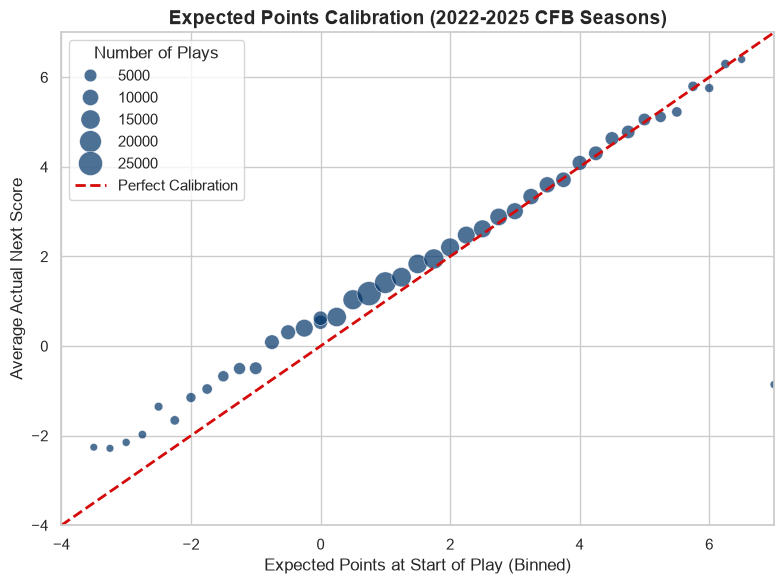

In [ ]:
#Model calibration plot function adapted for the college football data
def plot_calibration(df, bin_width=0.25, min_plays=50, title_suffix="2022-2025 CFB Seasons"):
    df_copy = df.copy()
    df_copy['ep_bin'] = (df_copy['EP_start'] / bin_width).round() * bin_width

    cal_data = df_copy.groupby('ep_bin').agg(
        actual_pts=('pts_next_score', 'mean'),
        plays=('pts_next_score', 'count')
    ).reset_index()

    cal_data = cal_data[cal_data['plays'] >= min_plays]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=cal_data, x='ep_bin', y='actual_pts', size='plays',
        sizes=(30, 300), color='#013369', alpha=0.7, ax=ax
    )

    axis_min = np.floor(min(cal_data['ep_bin'].min(), cal_data['actual_pts'].min()))
    axis_max = np.ceil(max(cal_data['ep_bin'].max(), cal_data['actual_pts'].max()))
    ax.plot(
        [axis_min, axis_max], [axis_min, axis_max],
        linestyle='--', color='#D50A0A', linewidth=2,
        label='Perfect Calibration'
    )

    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    ax.set_title(f"Expected Points Calibration ({title_suffix})", fontweight='bold', fontsize=14)
    ax.set_xlabel("Expected Points at Start of Play (Binned)")
    ax.set_ylabel("Average Actual Next Score")
    ax.legend(title="Number of Plays", loc="upper left")
    plt.tight_layout()
    plt.show()

plot_calibration(fbs_pbp_filtered)

*INTERPRETATION*

IF I did this right... AND am interpreting the plot(s) the right way... there is an evident difference between the EP models of college and pro football. The slope of cfb's model is smaller than that of the real calibration line and the NFL model. The most noticeable difference is the strength of each model's calibration; while the NFL model is, for the most part, parallel to the real calibration line, my model has somewhat of a flatter slope, only curving and lining up with the calibration line for the higher-valued positive score options. Another related finding is that the college model is more conservative at predicting points, as seen by the larger gap between the bins towards the bottom left of the line. 

In [ ]:
import nfl_data_py as nfl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [ ]:
#NFL Data
nfl_pbp_raw = nfl.import_pbp_data([2021, 2022, 2023, 2024, 2025])
print(nfl_pbp_raw.shape)
print(nfl_pbp_raw.columns[:30].tolist())
print(nfl_pbp_raw['play_type'].value_counts().head(10))

2021 done.
2022 done.
2023 done.
2024 done.
2025 done.
Downcasting floats.
(247284, 396)
['play_id', 'game_id', 'old_game_id', 'home_team', 'away_team', 'season_type', 'week', 'posteam', 'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'game_half', 'quarter_end', 'drive', 'sp', 'qtr', 'down', 'goal_to_go', 'time', 'yrdln', 'ydstogo', 'ydsnet', 'desc', 'play_type', 'yards_gained']
play_type
pass           101870
run             74608
no_play         23494
kickoff         14467
punt            10994
extra_point      6450
field_goal       5594
qb_kneel         2193
qb_spike          361
Name: count, dtype: int64


In [ ]:
# filter to valid NFL plays and print the rows left before the 3rd-down split
# this helps diagnose the zero-row issue immediately
nfl_raw = nfl_pbp_raw.copy()

# coerce columns that are often nullable to numeric or strings
nfl_raw['wp'] = pd.to_numeric(nfl_raw.get('wp', pd.Series(np.nan, index=nfl_raw.index)), errors='coerce')
nfl_raw['yardline_100'] = pd.to_numeric(nfl_raw.get('yardline_100', pd.Series(np.nan, index=nfl_raw.index)), errors='coerce')
nfl_raw['ydstogo'] = pd.to_numeric(nfl_raw.get('ydstogo', pd.Series(np.nan, index=nfl_raw.index)), errors='coerce')
nfl_raw['game_seconds_remaining'] = pd.to_numeric(nfl_raw.get('game_seconds_remaining', pd.Series(np.nan, index=nfl_raw.index)), errors='coerce')
nfl_raw['play_type'] = nfl_raw.get('play_type', pd.Series('', index=nfl_raw.index)).astype(str).str.lower()

nfl_filtered = nfl_raw[
    (nfl_raw['posteam'].notna()) &
    (nfl_raw['yardline_100'].between(20, 80)) &
    (nfl_raw['game_seconds_remaining'] > 60) &
    (nfl_raw['play_type'].isin(['pass', 'run', 'rush'])) &
    (nfl_raw['ydstogo'] <= 20) &
    (~nfl_raw['play_type'].isin(['kickoff', 'extra_point', 'two_point_attempt', 'field_goal', 'punt'])) &
    (nfl_raw['wp'].le(0.95))
].copy()

print('nfl_pbp_raw shape:', nfl_pbp_raw.shape)
print('nfl_filtered shape:', nfl_filtered.shape)
print('play_type values:', sorted(nfl_raw['play_type'].dropna().unique())[:20])
print('wp missing count:', nfl_raw['wp'].isna().sum())

nfl_filtered.head()

nfl_pbp_raw shape: (247284, 396)
nfl_filtered shape: (124158, 396)
play_type values: ['extra_point', 'field_goal', 'kickoff', 'no_play', 'pass', 'punt', 'qb_kneel', 'qb_spike', 'run']
wp missing count: 1424


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,was_pressure,route,defense_man_zone_type,defense_coverage_type,offense_names,defense_names,offense_positions,defense_positions,offense_numbers,defense_numbers
2,55.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,76.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,False,ANGLE,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,TEN,home,ARI,...,False,HITCH,ZONE_COVERAGE,COVER_6,NaN,NaN,NaN,NaN,NaN,NaN
6,152.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,ARI,away,TEN,...,False,GO,ZONE_COVERAGE,COVER_3,NaN,NaN,NaN,NaN,NaN,NaN
7,181.0,2021_01_ARI_TEN,2021091207,TEN,ARI,REG,1,ARI,away,TEN,...,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# filter to 3rd downs and create the target variable
nfl3rd = nfl_filtered[nfl_filtered['down'] == 3].copy()
nfl3rd['season'] = nfl3rd['season']
nfl3rd['success'] = np.where(nfl3rd['first_down'] == 1, 1, 0)

print('nfl3rd shape:', nfl3rd.shape)
print(nfl3rd[['season', 'down', 'play_type', 'ydstogo', 'yardline_100', 'wp', 'first_down', 'success']].head())

#create team-based 3rd down averages, flipping for defensive success rates
offRush = nfl3rd[nfl3rd['play_type'] == 'run'].groupby(['season', 'posteam']).agg({"success": "mean"})
offPass = nfl3rd[nfl3rd['play_type'] == 'pass'].groupby(['season', 'posteam']).agg({"success": "mean"})
defRush = 1 - (nfl3rd[nfl3rd['play_type'] == 'run'].groupby(['season', 'defteam']).agg({"success": "mean"}))
defPass = 1 - (nfl3rd[nfl3rd['play_type'] == 'pass'].groupby(['season', 'defteam']).agg({"success": "mean"}))


nfl3rd shape: (24868, 396)
    season  down play_type  ydstogo  yardline_100        wp  first_down  \
4     2021   3.0      pass     10.0          75.0  0.498319         0.0   
34    2021   3.0      pass      3.0          58.0  0.746093         0.0   
42    2021   3.0      pass      9.0          67.0  0.222600         0.0   
72    2021   3.0      pass     10.0          75.0  0.810423         1.0   
77    2021   3.0      pass      6.0          41.0  0.846890         1.0   

    success  
4         0  
34        0  
42        0  
72        1  
77        1  


In [70]:
# Model
# use 2021-2024 as training and 2025 as holdout
test_season = 2025
train = nfl3rd[nfl3rd['season'] != test_season].copy()
test = nfl3rd[nfl3rd['season'] == test_season].copy()

# print('train before merge:', train.shape)
# print('test before merge:', test.shape)

# Create team season rates on training data only
offPass = (
    train[train['play_type'] == 'pass']
    .groupby(['season', 'posteam'], as_index=False)
    .agg(off_pass_3rd_rate=('success', 'mean'))
)
offRush = (
    train[train['play_type'] == 'run']
    .groupby(['season', 'posteam'], as_index=False)
    .agg(off_run_3rd_rate=('success', 'mean'))
)
defPass = (
    train[train['play_type'] == 'pass']
    .groupby(['season', 'defteam'], as_index=False)
    .agg(def_pass_3rd_rate=('success', 'mean'))
)
defRush = (
    train[train['play_type'] == 'run']
    .groupby(['season', 'defteam'], as_index=False)
    .agg(def_run_3rd_rate=('success', 'mean'))
)

# merge the new team-season features back into the train and test sets
train = train.merge(offPass, on=['season', 'posteam'], how='left')
train = train.merge(offRush, on=['season', 'posteam'], how='left')
train = train.merge(defPass, on=['season', 'defteam'], how='left')
train = train.merge(defRush, on=['season', 'defteam'], how='left')

test = test.merge(offPass, on=['season', 'posteam'], how='left')
test = test.merge(offRush, on=['season', 'posteam'], how='left')
test = test.merge(defPass, on=['season', 'defteam'], how='left')
test = test.merge(defRush, on=['season', 'defteam'], how='left')

# fill any missing team rate with the training average
rate_cols = ['off_pass_3rd_rate', 'off_run_3rd_rate',
             'def_pass_3rd_rate', 'def_run_3rd_rate']

for col in rate_cols:
    train[col] = train[col].fillna(train[col].mean())
    test[col] = test[col].fillna(train[col].mean())

model_cols = [
    'season', 'ydstogo', 'play_type', 'yardline_100',
    'off_pass_3rd_rate', 'off_run_3rd_rate',
    'def_pass_3rd_rate', 'def_run_3rd_rate', 'success'
]

train = train.dropna(subset=model_cols).copy()
test = test.dropna(subset=model_cols).copy()

# print('train after cleaning:', train.shape)
# print('test after cleaning:', test.shape)
# print('train missing counts:\n', train.isna().sum())
# print('test missing counts:\n', test.isna().sum())

model_formula = """
success ~ C(season) + ydstogo + C(play_type) + yardline_100 +
          off_pass_3rd_rate + off_run_3rd_rate +
          def_pass_3rd_rate + def_run_3rd_rate
"""

model = smf.logit(model_formula, data=train).fit(disp=False)
print(model.summary())


                           Logit Regression Results                           
Dep. Variable:                success   No. Observations:                19934
Model:                          Logit   Df Residuals:                    19923
Method:                           MLE   Df Model:                           10
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.1004
Time:                        14:13:45   Log-Likelihood:                -12215.
converged:                       True   LL-Null:                       -13578.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.8872      0.234    -12.329      0.000      -3.346      -2.428
C(season)[T.2022]       0.0536      0.044      1.220      0.222      -0.032       0.140
C(season)[T.2023

*INTERPRETATION OF RESULTS*
This part was challenging. I didn't completely know where to start, and just trying to get the model to run took more effort than being able to interpret the results or adding any extra features (i.e. I left "success" as defined only by a converted 3rd down instead of the extra potential success options). Additionally, I couldn't remember what other features we included in our model (my notes only mention the offensive and defensive stats), and also couldn't remember HOW exactly we handled things like time remaining, etc. so I just left it simple. I did flip the defensive run/pass stats to be in favor of the defense (they were originally reflecting if the defense gave up a conversion, but I wanted it to reflect it as a "success" for the defense by NOT giving one up. Overall, the model seems to be significantly effective, as the r-squared and LLR p-value both reflect. All four offense/defense run/pass splits are statistically significant, meaning teams do NOT all have the same effectiveness at 3rd & X. The gap between rushing and passing is evident, with rushing success being less varied compared to passing plays. Other than that, I would maybe like some more help interpreting the results if we had time? I'm just not sure how applicable my model is based on the limited features it accounts for, and some of the coefficients and result values are a little confusing.

*AI USAGE*
Again, I used AI for finding the right feature names, finding and fixing errors, and at points in Part 2 for building a starting point/editing the model, especially as I ran into a bunch of problems in its deployment. 